In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load (no trust_remote_code)
dataset = load_dataset('descartes100/enhanced-financial-phrasebank')
print("Dataset:", dataset)

# Handle nested structure: df['train'] is dict-like rows
rows = dataset['train']['train']
df = pd.DataFrame(rows)
label_names = ['negative', 'neutral', 'positive']

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Labels:\n", df['label'].value_counts().sort_index().to_dict())

X = df['sentence']
y = df['label']
rando = 67

# Split & vectorize
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rando, stratify=y)
vectorizer = TfidfVectorizer(max_features=2000, stop_words='english', min_df=2, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vectorizer shape:", X_train_vec.shape)

Dataset: DatasetDict({
    train: Dataset({
        features: ['train'],
        num_rows: 4846
    })
})
Shape: (4846, 2)
Columns: ['label', 'sentence']
Labels:
 {0: 604, 1: 2879, 2: 1363}
Vectorizer shape: (3876, 2000)


##### Naive Bayes


MultinomialNB Results:
Accuracy: 0.7526
              precision    recall  f1-score   support

    negative       0.85      0.72      0.78       121
     neutral       0.74      0.92      0.82       576
    positive       0.75      0.42      0.54       273

    accuracy                           0.75       970
   macro avg       0.78      0.68      0.71       970
weighted avg       0.76      0.75      0.73       970



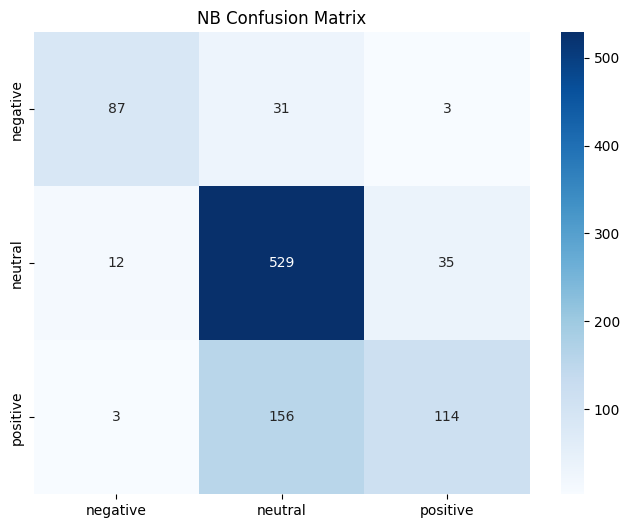

In [2]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB(alpha=1.0, class_prior=None) 
model_nb.fit(X_train_vec, y_train)
y_pred_nb = model_nb.predict(X_test_vec)

print("\nMultinomialNB Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb, target_names=label_names))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('NB Confusion Matrix')
# plt.savefig('twitter_nb_cm.png', dpi=300)
plt.show()


##### Logistic Regression


Logistic Regression Results:
Accuracy: 0.7691
              precision    recall  f1-score   support

    negative       0.90      0.66      0.76       121
     neutral       0.76      0.91      0.83       576
    positive       0.76      0.51      0.61       273

    accuracy                           0.77       970
   macro avg       0.80      0.70      0.73       970
weighted avg       0.77      0.77      0.76       970



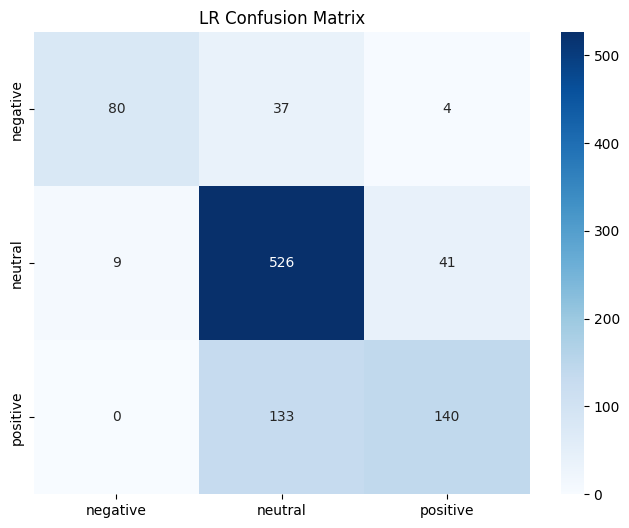

In [3]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, random_state=rando)
model_lr.fit(X_train_vec, y_train)
y_pred_lr = model_lr.predict(X_test_vec)

print("\nLogistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=label_names))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('LR Confusion Matrix')
# plt.savefig('twitter_lr_cm.png', dpi=300)
plt.show()

##### SVM


SVM Results:
Accuracy: 0.7763
              precision    recall  f1-score   support

    negative       0.85      0.71      0.77       121
     neutral       0.76      0.91      0.83       576
    positive       0.78      0.52      0.62       273

    accuracy                           0.78       970
   macro avg       0.80      0.71      0.74       970
weighted avg       0.78      0.78      0.77       970



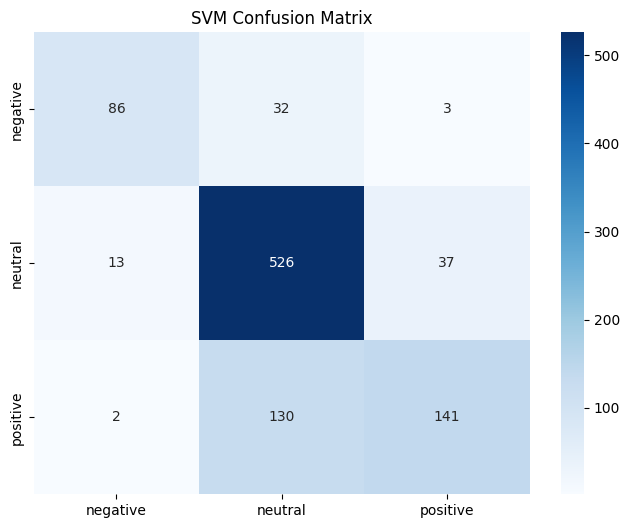

In [4]:
from sklearn.svm import SVC

model_svm = SVC(kernel='linear', random_state=rando, probability=True)
model_svm.fit(X_train_vec, y_train)
y_pred_svm = model_svm.predict(X_test_vec)

print("\nSVM Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=label_names))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('SVM Confusion Matrix')
# plt.savefig('twitter_svm_cm.png', dpi=300)
plt.show()

##### XGBoost

XGBoost Results:
Accuracy: 0.7753
              precision    recall  f1-score   support

    negative       0.86      0.64      0.74       121
     neutral       0.75      0.94      0.84       576
    positive       0.82      0.48      0.61       273

    accuracy                           0.78       970
   macro avg       0.81      0.69      0.73       970
weighted avg       0.79      0.78      0.76       970



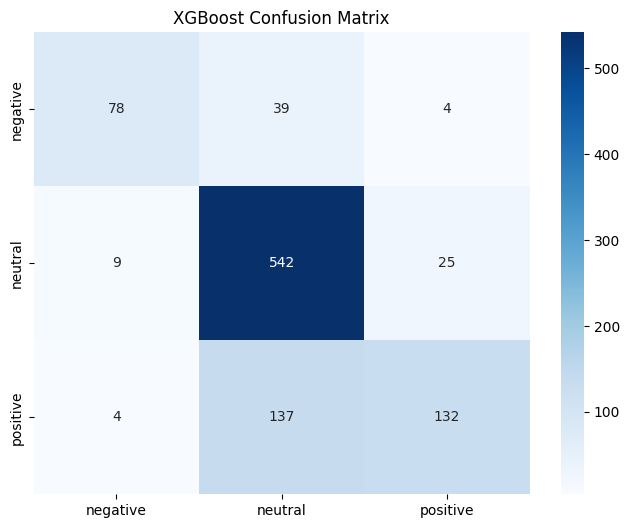


Top 10 ngram features: ['decrease', 'improvement', 'positive development', 'downturn', 'increase', 'challenges', 'positive', 'profit', 'decline', 'challenging']


In [5]:
import xgboost as xgb
# XGBoost (tuned for small dataset)
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=4,  # Shallower for text features
    learning_rate=0.1,
    n_estimators=150,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=rando,
    eval_metric='mlogloss'
)
model.fit(X_train_vec, y_train, verbose=False)

# Results
y_pred = model.predict(X_test_vec)
print("XGBoost Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=label_names))

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('XGBoost Confusion Matrix')
# plt.savefig('xgb_cm.png', dpi=300)
plt.show()

# Top features
importances = model.feature_importances_
top_idx = np.argsort(importances)[-10:]
top_features = [vectorizer.get_feature_names_out()[i] for i in top_idx]
print("\nTop 10 ngram features:", top_features)

##### LightGBM

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[150]	valid_0's multi_logloss: 0.543774
LightGBM Results:
Accuracy: 0.7649
              precision    recall  f1-score   support

    negative       0.84      0.62      0.71       121
     neutral       0.75      0.93      0.83       576
    positive       0.80      0.48      0.60       273

    accuracy                           0.76       970
   macro avg       0.80      0.68      0.72       970
weighted avg       0.77      0.76      0.75       970



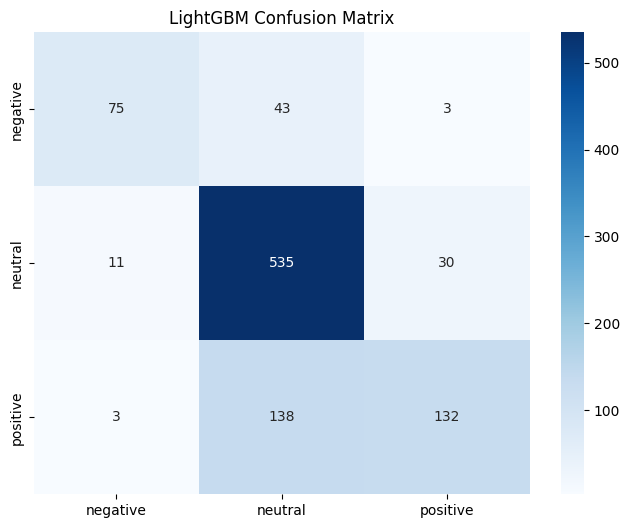

In [6]:
import lightgbm as lgb
# LightGBM Dataset
train_data = lgb.Dataset(X_train_vec, label=y_train)
test_data = lgb.Dataset(X_test_vec, label=y_test, reference=train_data)

# Params (optimized for multiclass text)
params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'max_depth': 4,
    'learning_rate': 0.1,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'verbose': -1,
    'random_state': rando
}

# Train
model = lgb.train(params, train_data, num_boost_round=150, valid_sets=[test_data], callbacks=[lgb.early_stopping(10)])

# Predict
y_pred = np.argmax(model.predict(X_test_vec), axis=1)
print("LightGBM Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=label_names))

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('LightGBM Confusion Matrix')
# plt.savefig('lgb_cm.png', dpi=300)
plt.show()

##### Sentiment Metrics Results

In [7]:
from sentiment_metrics import compute_all_metrics
metrics = compute_all_metrics(y_true=y_test.tolist(), y_pred=y_pred_nb.tolist())
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Macro F1: {metrics['macro_f1']:.4f}")
print(f"S-MAE:    {metrics['s_mae']:.4f}")
for cls, vals in metrics['per_class'].items():
    print(f"  {cls}: P={vals['precision']:.2f} R={vals['recall']:.2f} F1={vals['f1']:.2f}")

Accuracy: 0.7526
Macro F1: 0.7119
S-MAE:    0.2536
  negative: P=0.85 R=0.72 F1=0.78
  neutral: P=0.74 R=0.92 F1=0.82
  positive: P=0.75 R=0.42 F1=0.54


In [8]:
# ── Unified evaluation using sentiment_metrics.py ──────────────────────────
from sentiment_metrics import compute_all_metrics

models_preds = {
    "Naive Bayes":         y_pred_nb,
    "Logistic Regression": y_pred_lr,
    "SVM":                 y_pred_svm,
    "LightGBM":            y_pred,      # LightGBM uses y_pred directly
}

for model_name, y_pred_model in models_preds.items():
    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    
    metrics = compute_all_metrics(
        y_true=y_test.tolist(),
        y_pred=y_pred_model.tolist(),
        # int_label_scheme="phrasebank" is default (0=neg, 1=neu, 2=pos)
    )
    
    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"Macro F1 : {metrics['macro_f1']:.4f}")
    print(f"S-MAE    : {metrics['s_mae']:.4f}")
    print("\nPer-class breakdown:")
    for cls, vals in metrics['per_class'].items():
        print(f"  {cls:10s}  P={vals['precision']:.3f}  R={vals['recall']:.3f}  F1={vals['f1']:.3f}  support={int(vals['support'])}")


  Naive Bayes
Accuracy : 0.7526
Macro F1 : 0.7119
S-MAE    : 0.2536

Per-class breakdown:
  negative    P=0.853  R=0.719  F1=0.780  support=121
  neutral     P=0.739  R=0.918  F1=0.819  support=576
  positive    P=0.750  R=0.418  F1=0.536  support=273

  Logistic Regression
Accuracy : 0.7691
Macro F1 : 0.7334
S-MAE    : 0.2351

Per-class breakdown:
  negative    P=0.899  R=0.661  F1=0.762  support=121
  neutral     P=0.756  R=0.913  F1=0.827  support=576
  positive    P=0.757  R=0.513  F1=0.611  support=273

  SVM
Accuracy : 0.7763
Macro F1 : 0.7427
S-MAE    : 0.2289

Per-class breakdown:
  negative    P=0.851  R=0.711  F1=0.775  support=121
  neutral     P=0.765  R=0.913  F1=0.832  support=576
  positive    P=0.779  R=0.516  F1=0.621  support=273

  LightGBM
Accuracy : 0.7649
Macro F1 : 0.7151
S-MAE    : 0.2412

Per-class breakdown:
  negative    P=0.843  R=0.620  F1=0.714  support=121
  neutral     P=0.747  R=0.929  F1=0.828  support=576
  positive    P=0.800  R=0.484  F1=0.603  sup